In [9]:
import pandas as pd

df = pd.read_csv("car_maintenance_dataset_expanded.csv")

print(df.head())
print(df.info())
print(df.describe())

   car_id         part  current_km  km_diff  days_diff  needs_change  \
0      21      battery       96160    33520        154             0   
1      36          oil      126032       75        213             0   
2      25        tires      104578    44315        320             0   
3      46      battery      177280    22368        938             0   
4      26  spark_plugs       72819    28827        458             0   

   last_change_km  
0         62640.0  
1             NaN  
2         60263.0  
3        154912.0  
4         43992.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   car_id          110000 non-null  int64  
 1   part            110000 non-null  object 
 2   current_km      110000 non-null  int64  
 3   km_diff         110000 non-null  int64  
 4   days_diff       110000 non-null  int64  
 5   needs_chan

In [11]:
print(df["needs_change"].value_counts())
print(df["needs_change"].value_counts(normalize=True))

needs_change
0    70145
1    39855
Name: count, dtype: int64
needs_change
0    0.637682
1    0.362318
Name: proportion, dtype: float64


##Distribution of Numerical Features

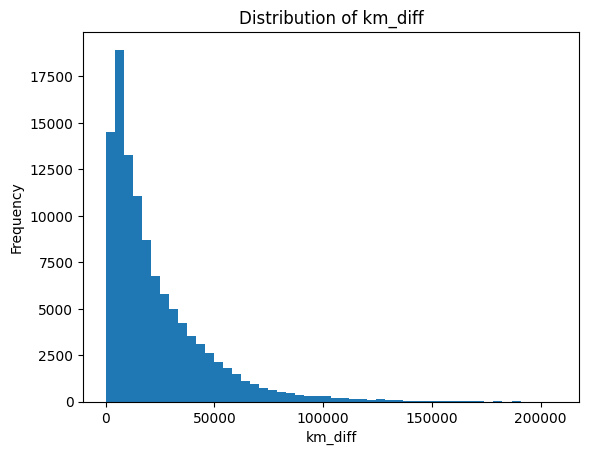

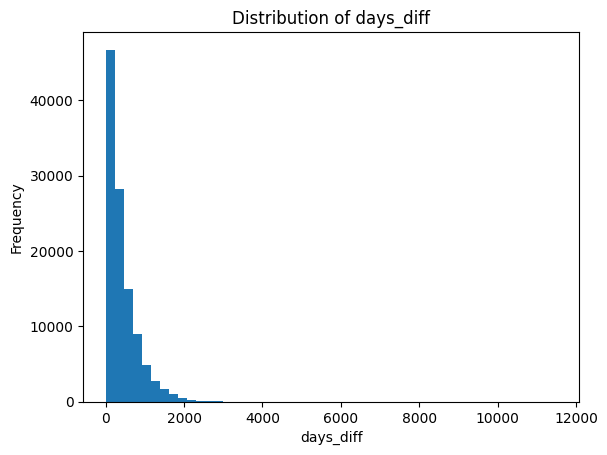

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["km_diff"], bins=50)
plt.title("Distribution of km_diff")
plt.xlabel("km_diff")
plt.ylabel("Frequency")
plt.show()

plt.hist(df["days_diff"], bins=50)
plt.title("Distribution of days_diff")
plt.xlabel("days_diff")
plt.ylabel("Frequency")
plt.show()

##km_diff vs needs_change

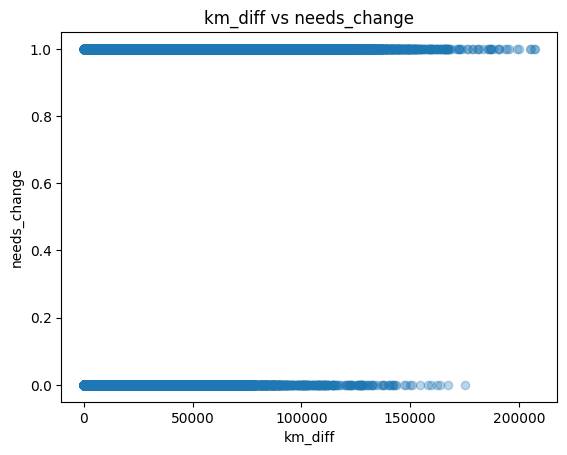

In [13]:
plt.scatter(df["km_diff"], df["needs_change"], alpha=0.3)
plt.title("km_diff vs needs_change")
plt.xlabel("km_diff")
plt.ylabel("needs_change")
plt.show()

##Parts Distribution

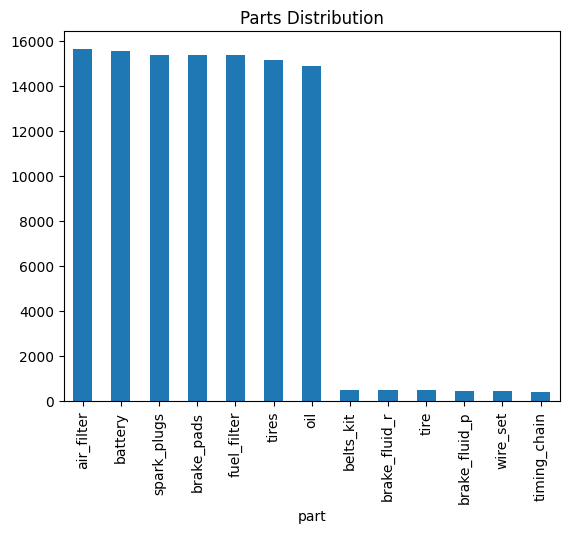

In [14]:
df["part"].value_counts().plot(kind="bar")
plt.title("Parts Distribution")
plt.show()

##Failure Rate per Part

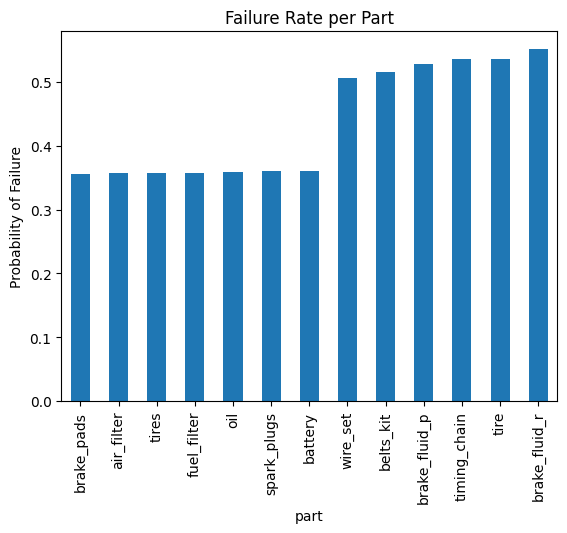

In [15]:
part_failure = df.groupby("part")["needs_change"].mean()
part_failure.sort_values().plot(kind="bar")

plt.title("Failure Rate per Part")
plt.ylabel("Probability of Failure")
plt.show()

##km_diff vs Part

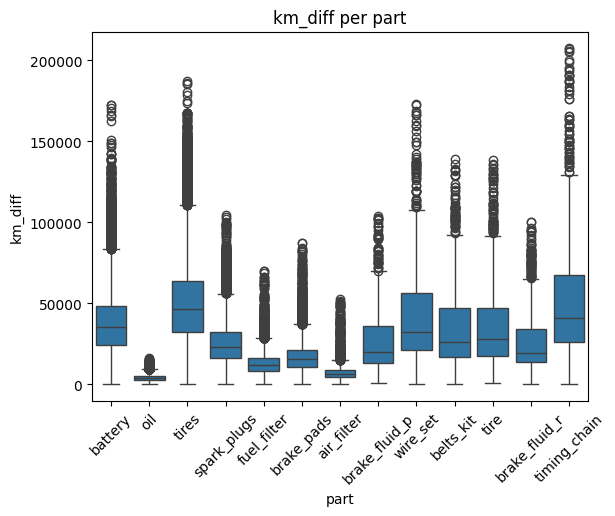

In [16]:
import seaborn as sns

sns.boxplot(x="part", y="km_diff", data=df)
plt.xticks(rotation=45)
plt.title("km_diff per part")
plt.show()

##Correlation Matrix

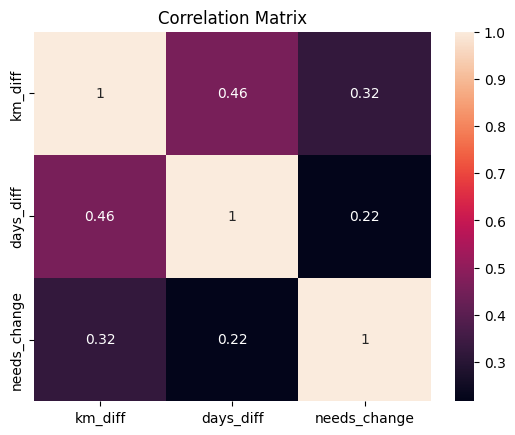

In [17]:
import seaborn as sns

corr = df[["km_diff", "days_diff", "needs_change"]].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()